# 👨‍💻 About the Author

Welcome to this comprehensive tutorial! This notebook is curated and maintained by **Mohammad Javad Ahmadi**, a specialist in bridging the gap between cutting-edge AI research and production-grade software.

### **Mohammad Javad Ahmadi**
*CTO at MediversAI | Head of ARAS AI Group | Ph.D. Candidate in Electrical & Control Engineering*

With over 8 years of experience in architecting complex AI pipelines, Mohammad Javad leads technical teams in developing scalable SaaS solutions for **MedTech** and **FinTech**. His expertise includes:

*   **Advanced Computer Vision:** Real-time surgical video understanding, 3D-CNNs, and medical imaging analysis.
*   **Generative AI:** Multi-modal GenAI (LLMs/VLMs) and Autonomous Agentic Systems.
*   **Technical Leadership:** Directing R&D strategies and mentoring 60+ developers and researchers.

He has been recognized as an innovation leader by **Alberta Machine Intelligence Institute (Amii)** and has received prestigious grants for his work on AI-powered surgical assessment systems.

---
*Connect or explore more:*
[![LinkedIn](https://img.shields.io/badge/LinkedIn-Profile-blue?style=flat&logo=linkedin)](https://www.linkedin.com/in/mjahmadi/)
[![GitHub](https://img.shields.io/badge/GitHub-Profile-black?style=flat&logo=github)](https://github.com/MJAHMADEE)
[![Google Scholar](https://img.shields.io/badge/Google%20Scholar-Publications-red?style=flat&logo=google-scholar)](https://scholar.google.com/citations?user=wTnN9IEAAAAJ&hl=en)

# Deep Learning, Neural Networks, and PyTorch — A Comprehensive Tutorial

**Course:** Robotics and Machine Vision  
**Module:** Introduction to Deep Learning (pre-CNN)  
**Format:** Self-contained Google Colab notebook

---

## What this notebook covers

This notebook bridges the gap between classical image processing and convolutional neural networks. By the end, you will have built, trained, debugged, and analyzed neural networks **from scratch with NumPy** and **with PyTorch**, on both toy and real datasets, with full understanding of every component.

We will go from a single artificial neuron all the way to deep multilayer perceptrons trained on image data with GPU acceleration — and along the way we will cover *every* practical detail that matters in real-world deep learning.

## Table of Contents

**Part 1 — PyTorch Foundations**
1. Setup, environment check, and GPU access
2. Tensors: the fundamental data structure
3. Tensor operations, broadcasting, indexing, reshaping
4. NumPy ↔ PyTorch interoperability
5. Working with GPUs (CUDA): when, why, and how
6. Autograd: automatic differentiation explained

**Part 2 — Deep Learning Theory and Practice**
7. Understanding perceptrons (theory + from-scratch implementation)
8. The XOR problem and why one neuron is not enough
9. Multilayer perceptrons: architecture, hidden layers, capacity
10. Activation functions: a complete tour with comparisons
11. The feedforward process: from inputs to predictions
12. Error (loss) functions: MSE, cross-entropy, and friends
13. Optimization: batch / stochastic / mini-batch gradient descent
14. Backpropagation: the chain rule, step by step

**Part 3 — Building Real Neural Networks in PyTorch**
15. `torch.nn`, `nn.Module`, and the PyTorch API
16. Datasets and `DataLoader`
17. Training and evaluation loops
18. A complete MLP for image classification (Fashion-MNIST)
19. Regularization: weight decay, dropout, batch normalization
20. Weight initialization strategies
21. Optimizers beyond SGD: Momentum, RMSProp, Adam, AdamW
22. Learning-rate schedules
23. Diagnosing training: bias, variance, learning curves
24. Saving, loading, and reproducibility
25. What's next — bridge to CNNs


---
# Part 1 — PyTorch Foundations

## 1. Setup and environment check

Google Colab comes with PyTorch pre-installed. The cell below verifies the installation, prints version info, and detects whether a GPU is available.

> **GPU tip:** In Colab, go to *Runtime → Change runtime type → Hardware accelerator → GPU* (T4 is free). Without a GPU, the later training experiments still work but will be slower.


In [ ]:
# Standard scientific stack — all pre-installed in Colab
import sys
import platform
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

print(f"Python  : {sys.version.split()[0]}")
print(f"Platform: {platform.platform()}")
print(f"NumPy   : {np.__version__}")
print(f"PyTorch : {torch.__version__}")
print()
print(f"CUDA available : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA version   : {torch.version.cuda}")
    print(f"GPU device     : {torch.cuda.get_device_name(0)}")
    print(f"GPU memory     : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("No GPU detected — code will run on CPU (slower for large models).")

# Set a global default device variable we'll use throughout the notebook
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nUsing device: {device}")


Python  : 3.12.13
Platform: Linux-6.6.113+-x86_64-with-glibc2.35
NumPy   : 2.0.2
PyTorch : 2.10.0+cu128

CUDA available : True
CUDA version   : 12.8
GPU device     : Tesla T4
GPU memory     : 15.64 GB

Using device: cuda


### A note on reproducibility

Deep learning involves randomness: weight initialization, mini-batch shuffling, dropout, etc. To get **reproducible results**, we seed every relevant random source.


In [ ]:
def set_seed(seed: int = 42):
    # Seed Python, NumPy, and PyTorch (CPU + GPU) for reproducibility.
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    # Make CuDNN deterministic (slightly slower, but reproducible)
    torch.backends.cudnn.deterministic = True #Forces cuDNN to only use algorithms where the order of operations is strictly controlled. This guarantees that if you give it the same input, it will give you the exact same output every single time.
    torch.backends.cudnn.benchmark = False

set_seed(42)
print("All random seeds set to 42.")


All random seeds set to 42.


---
## 2. Tensors — the fundamental data structure

A **tensor** is the central object in PyTorch. Conceptually it is just a multi-dimensional array (like a NumPy `ndarray`), but with two superpowers:

1. It can live on a **GPU** for massively parallel computation.
2. It can record operations to enable **automatic differentiation** (autograd).

### Tensor terminology

| Rank | Name      | Example                                | Shape       |
|------|-----------|----------------------------------------|-------------|
| 0    | Scalar    | `3.14`                                 | `()`        |
| 1    | Vector    | `[1, 2, 3]`                            | `(3,)`      |
| 2    | Matrix    | `[[1,2],[3,4]]`                        | `(2, 2)`    |
| 3    | 3-tensor  | A single RGB image (C×H×W)             | `(3, H, W)` |
| 4    | 4-tensor  | A *batch* of RGB images (N×C×H×W)      | `(N,3,H,W)` |

In deep learning, the **first dimension is almost always the batch dimension**.


In [ ]:
# --- Creating tensors from data ---
scalar  = torch.tensor(3.14)
vector  = torch.tensor([1.0, 2.0, 3.0])
matrix  = torch.tensor([[1, 2, 3],
                        [4, 5, 6]])
tensor3 = torch.randn(3, 4, 5)   # rank-3, normal distribution

for name, t in [("scalar", scalar), ("vector", vector),
                ("matrix", matrix), ("tensor3", tensor3)]:
    print(f"{name:8s}  shape={tuple(t.shape)}  ndim={t.ndim}  dtype={t.dtype}")


scalar    shape=()  ndim=0  dtype=torch.float32
vector    shape=(3,)  ndim=1  dtype=torch.float32
matrix    shape=(2, 3)  ndim=2  dtype=torch.int64
tensor3   shape=(3, 4, 5)  ndim=3  dtype=torch.float32


In [ ]:
# --- Common constructors ---
print("zeros(2,3):\n",  torch.zeros(2, 3))
print("\nones(2,3):\n",   torch.ones(2, 3))
print("\neye(3):\n",      torch.eye(3))                        # identity
print("\narange(0,10,2):", torch.arange(0, 10, 2))
print("\nlinspace(0,1,5):", torch.linspace(0, 1, 5))
print("\nrandn(2,3):\n",   torch.randn(2, 3))                  # N(0,1)
print("\nrand(2,3):\n",    torch.rand(2, 3))                   # U(0,1)
print("\nrandint(0,10,(2,3)):\n", torch.randint(0, 10, (2, 3)))


zeros(2,3):
 tensor([[0., 0., 0.],
        [0., 0., 0.]])

ones(2,3):
 tensor([[1., 1., 1.],
        [1., 1., 1.]])

eye(3):
 tensor([[1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.]])

arange(0,10,2): tensor([0, 2, 4, 6, 8])

linspace(0,1,5): tensor([0.0000, 0.2500, 0.5000, 0.7500, 1.0000])

randn(2,3):
 tensor([[-0.3870,  0.9912,  0.4679],
        [-0.2049, -0.7409,  0.3618]])

rand(2,3):
 tensor([[0.2477, 0.6524, 0.6057],
        [0.3725, 0.7980, 0.8399]])

randint(0,10,(2,3)):
 tensor([[1, 5, 1],
        [9, 1, 4]])


### Data types (`dtype`) matter

Choosing the right `dtype` affects **memory**, **speed**, and **numerical accuracy**. In deep learning we mostly use `float32` (single precision). On modern GPUs, `float16` / `bfloat16` are used for *mixed-precision* training to roughly double throughput.


In [ ]:
x_f32 = torch.tensor([1.0, 2.0, 3.0], dtype=torch.float32)
x_f64 = torch.tensor([1.0, 2.0, 3.0], dtype=torch.float64)
x_i64 = torch.tensor([1, 2, 3],          dtype=torch.int64)   # default integer type
x_bool = torch.tensor([True, False, True])

for name, t in [("float32", x_f32), ("float64", x_f64),
                ("int64", x_i64), ("bool", x_bool)]:
    print(f"{name:8s}  dtype={t.dtype}  bytes/elem={t.element_size()}  total={t.numel() * t.element_size()} B")

# Casting
print("\nCast f32 -> f64:", x_f32.to(torch.float64).dtype)
print("Cast f32 -> int :", x_f32.to(torch.int32))


float32   dtype=torch.float32  bytes/elem=4  total=12 B
float64   dtype=torch.float64  bytes/elem=8  total=24 B
int64     dtype=torch.int64  bytes/elem=8  total=24 B
bool      dtype=torch.bool  bytes/elem=1  total=3 B

Cast f32 -> f64: torch.float64
Cast f32 -> int : tensor([1, 2, 3], dtype=torch.int32)


---
## 3. Tensor operations, broadcasting, indexing, reshaping

### 3.1 Element-wise arithmetic


In [ ]:
a = torch.tensor([1.0, 2.0, 3.0])
b = torch.tensor([10.0, 20.0, 30.0])

print("a + b =", a + b)
print("a - b =", a - b)
print("a * b =", a * b)            # element-wise!
print("a / b =", a / b)
print("a ** 2 =", a ** 2)
print("torch.exp(a) =", torch.exp(a))
print("torch.log(a) =", torch.log(a))
print("torch.sqrt(a) =", torch.sqrt(a))


a + b = tensor([11., 22., 33.])
a - b = tensor([ -9., -18., -27.])
a * b = tensor([10., 40., 90.])
a / b = tensor([0.1000, 0.1000, 0.1000])
a ** 2 = tensor([1., 4., 9.])
torch.exp(a) = tensor([ 2.7183,  7.3891, 20.0855])
torch.log(a) = tensor([0.0000, 0.6931, 1.0986])
torch.sqrt(a) = tensor([1.0000, 1.4142, 1.7321])


### 3.2 Linear-algebra operations

The single most important operation in neural networks is the **matrix multiplication** `Y = X @ W + b`. PyTorch offers several APIs:

* `@` operator (Python 3.5+) — preferred
* `torch.matmul(A, B)` — same thing, more general
* `torch.mm(A, B)` — strictly 2-D × 2-D
* `torch.bmm(A, B)` — batched 2-D × 2-D


In [ ]:
A = torch.tensor([[1.0, 2.0],
                  [3.0, 4.0]])
B = torch.tensor([[5.0, 6.0],
                  [7.0, 8.0]])

print("Element-wise A * B:\n", A * B)
print("\nMatmul A @ B:\n", A @ B)
print("\nTranspose A.T:\n", A.T)
print("\nDeterminant:", torch.linalg.det(A).item())
print("Inverse A^-1:\n", torch.linalg.inv(A))

# Reductions
x = torch.arange(1., 7.).view(2, 3)
print("\nx =\n", x)
print("sum         :", x.sum().item())
print("sum(dim=0)  :", x.sum(dim=0))   # along rows -> per-column sum
print("sum(dim=1)  :", x.sum(dim=1))   # along cols -> per-row sum
print("mean        :", x.mean().item())
print("max         :", x.max().item())
print("argmax      :", x.argmax().item())


Element-wise A * B:
 tensor([[ 5., 12.],
        [21., 32.]])

Matmul A @ B:
 tensor([[19., 22.],
        [43., 50.]])

Transpose A.T:
 tensor([[1., 3.],
        [2., 4.]])

Determinant: -2.0
Inverse A^-1:
 tensor([[-2.0000,  1.0000],
        [ 1.5000, -0.5000]])

x =
 tensor([[1., 2., 3.],
        [4., 5., 6.]])
sum         : 21.0
sum(dim=0)  : tensor([5., 7., 9.])
sum(dim=1)  : tensor([ 6., 15.])
mean        : 3.5
max         : 6.0
argmax      : 5


### 3.3 Broadcasting

When two tensors have different shapes, PyTorch tries to **broadcast** them — virtually expanding the smaller one without copying memory. Rules (read shapes right-to-left):

1. Dimensions are compared element-wise.
2. Two dimensions are compatible if they are **equal** OR **one of them is 1**.
3. Missing dimensions are treated as size 1.

This is the cleanest way to add a bias vector to every row of a matrix.


In [ ]:
# A 4×3 matrix and a 3-vector — bias addition
X = torch.tensor([[1., 2., 3.],
                  [4., 5., 6.],
                  [7., 8., 9.],
                  [10.,11.,12.]])    # shape (4, 3)
b = torch.tensor([100., 200., 300.]) # shape (3,)  -> broadcasts to (1,3) -> (4,3)

print("X + b =\n", X + b)
print("\nShapes:  X={}, b={}".format(tuple(X.shape), tuple(b.shape)))

# Column vector broadcasting
col = torch.tensor([[10.], [20.], [30.], [40.]])    # (4,1)
print("\nX + column-bias =\n", X + col)


X + b =
 tensor([[101., 202., 303.],
        [104., 205., 306.],
        [107., 208., 309.],
        [110., 211., 312.]])

Shapes:  X=(4, 3), b=(3,)

X + column-bias =
 tensor([[11., 12., 13.],
        [24., 25., 26.],
        [37., 38., 39.],
        [50., 51., 52.]])


### 3.4 Indexing & slicing

Same syntax as NumPy — plus boolean masks and fancy indexing.


In [ ]:
x = torch.arange(20).view(4, 5)
print("x =\n", x)
print("\nx[0]      ->", x[0])              # first row
print("x[:, 2]   ->", x[:, 2])             # third column
print("x[1:3, :] ->\n", x[1:3, :])         # rows 1 and 2
print("x[-1, -1] ->", x[-1, -1].item())    # last element

# Boolean mask
mask = x > 10
print("\nmask:\n", mask)
print("x[x > 10] =", x[mask])


x =
 tensor([[ 0,  1,  2,  3,  4],
        [ 5,  6,  7,  8,  9],
        [10, 11, 12, 13, 14],
        [15, 16, 17, 18, 19]])

x[0]      -> tensor([0, 1, 2, 3, 4])
x[:, 2]   -> tensor([ 2,  7, 12, 17])
x[1:3, :] ->
 tensor([[ 5,  6,  7,  8,  9],
        [10, 11, 12, 13, 14]])
x[-1, -1] -> 19

mask:
 tensor([[False, False, False, False, False],
        [False, False, False, False, False],
        [False,  True,  True,  True,  True],
        [ True,  True,  True,  True,  True]])
x[x > 10] = tensor([11, 12, 13, 14, 15, 16, 17, 18, 19])


### 3.5 Reshaping: `view`, `reshape`, `permute`, `flatten`

Reshaping is constant in deep learning — e.g. flattening a `(N, 1, 28, 28)` image batch to `(N, 784)` for an MLP.

* `view`     — fast, requires *contiguous* memory.
* `reshape`  — works always (copies if needed).
* `permute`  — reorders axes (e.g. NHWC → NCHW).
* `transpose`— swaps two axes.
* `flatten` / `unsqueeze` / `squeeze` — common shape gymnastics.


In [ ]:
x = torch.arange(24)
print("Original:", x.shape)

x2 = x.view(2, 3, 4)
print("view(2,3,4):", x2.shape)

x3 = x.reshape(4, 6)
print("reshape(4,6):", x3.shape)

# Permute axes (key for image format conversions)
img_nhwc = torch.randn(2, 28, 28, 3)         # batch, H, W, C
img_nchw = img_nhwc.permute(0, 3, 1, 2)      # batch, C, H, W   <-- PyTorch convention
print("\nNHWC ->", img_nhwc.shape)
print("NCHW ->", img_nchw.shape)

# Add / remove singleton dimensions
v = torch.tensor([1., 2., 3.])
print("\nv.shape          =", v.shape)
print("v.unsqueeze(0)   =",  )   # (1,3) — row vector
print("v.unsqueeze(1)   =", v.unsqueeze(1).shape)   # (3,1) — column vector

m = torch.zeros(1, 3, 1, 4)
print("m.squeeze().shape=", m.squeeze().shape)      # remove all size-1 dims


Original: torch.Size([24])
view(2,3,4): torch.Size([2, 3, 4])
reshape(4,6): torch.Size([4, 6])

NHWC -> torch.Size([2, 28, 28, 3])
NCHW -> torch.Size([2, 3, 28, 28])

v.shape          = torch.Size([3])
v.unsqueeze(0)   = torch.Size([1, 3])
v.unsqueeze(1)   = torch.Size([3, 1])
m.squeeze().shape= torch.Size([3, 4])


---
## 4. NumPy ↔ PyTorch interoperability

CPU tensors and NumPy arrays can share the **same underlying memory** — converting is essentially free. This is great for plotting (matplotlib uses NumPy) and for using existing NumPy code.

> ⚠️ Sharing memory means modifying one modifies the other. To break the link, make a copy.


In [ ]:
# torch <-> numpy
t = torch.arange(6, dtype=torch.float32)
n = t.numpy()
print("torch  :", t)
print("numpy  :", n)

# Modify numpy array — torch tensor changes too!
n[0] = 99
print("\nAfter n[0] = 99 (memory is shared):")
print("torch  :", t)
print("numpy  :", n)

# Numpy -> torch
arr = np.array([1.0, 2.0, 3.0])
tt  = torch.from_numpy(arr)
print("\nfrom_numpy:", tt, tt.dtype)


torch  : tensor([0., 1., 2., 3., 4., 5.])
numpy  : [0. 1. 2. 3. 4. 5.]

After n[0] = 99 (memory is shared):
torch  : tensor([99.,  1.,  2.,  3.,  4.,  5.])
numpy  : [99.  1.  2.  3.  4.  5.]

from_numpy: tensor([1., 2., 3.], dtype=torch.float64) torch.float64


---
## 5. Working with GPUs (CUDA)

GPUs are *embarrassingly parallel* hardware that excels at the dense matrix arithmetic that powers neural networks. A single Colab T4 GPU can perform tens of teraflops in float32, making training **10×–100×** faster than CPU for typical networks.

### The golden rule
> **All tensors involved in a single operation must live on the same device.**

If your model is on the GPU, your inputs and labels must be on the GPU too. Mixing CPU and GPU tensors throws `RuntimeError`.

### Moving tensors

* `tensor.to(device)` — generic, works for any device.
* `tensor.cuda()` / `tensor.cpu()` — shortcuts.
* `model.to(device)` — moves all parameters and buffers.

### Pinned memory and async transfer

When loading data from CPU → GPU during training, **pinned memory** (`pin_memory=True` in `DataLoader`) plus `non_blocking=True` in `.to()` lets transfers overlap with computation.


In [ ]:
x_cpu = torch.randn(1000, 1000)
print(f"x_cpu device: {x_cpu.device}")

x_gpu = x_cpu.to(device)            # safe whether GPU or CPU
print(f"x_gpu device: {x_gpu.device}")

# A speed comparison: large matmul on CPU vs GPU
import time

def benchmark(device_, size=4096, repeats=3):
    a = torch.randn(size, size, device=device_)
    b = torch.randn(size, size, device=device_)
    # warm-up (especially important for GPU — kernel compilation)
    _ = a @ b
    if device_.type == "cuda":
        torch.cuda.synchronize()
    t0 = time.perf_counter()
    for _ in range(repeats):
        c = a @ b
    if device_.type == "cuda":
        torch.cuda.synchronize()        # wait for GPU work
    dt = (time.perf_counter() - t0) / repeats
    return dt

cpu_time = benchmark(torch.device("cpu"))
print(f"\n4096×4096 matmul on CPU: {cpu_time*1000:.1f} ms")

if torch.cuda.is_available():
    gpu_time = benchmark(torch.device("cuda"))
    print(f"4096×4096 matmul on GPU: {gpu_time*1000:.1f} ms")
    print(f"Speed-up: {cpu_time / gpu_time:.1f}×")
else:
    print("(GPU not available — skipping GPU benchmark)")


x_cpu device: cpu
x_gpu device: cuda:0

4096×4096 matmul on CPU: 1954.0 ms
4096×4096 matmul on GPU: 40.1 ms
Speed-up: 48.7×


### Common GPU-related pitfalls

| Pitfall                                              | Symptom                                | Fix                                              |
|------------------------------------------------------|----------------------------------------|--------------------------------------------------|
| Forgetting to move inputs                            | `Expected all tensors on the same dev` | `inputs = inputs.to(device)`                     |
| Forgetting to move the model                         | Same as above                          | `model.to(device)`                               |
| Calling `.numpy()` on a GPU tensor                   | `TypeError`                            | `tensor.cpu().numpy()`                           |
| Out-of-memory (OOM)                                  | `CUDA out of memory`                   | Smaller batch / `torch.cuda.empty_cache()` / use AMP |
| Accidentally keeping computation graphs around       | Memory leak                            | Wrap eval code in `with torch.no_grad():`        |


---
## 6. Autograd — automatic differentiation

This is the engine that powers all of deep learning. Whenever a tensor has `requires_grad=True`, PyTorch records every operation performed on it into a **computation graph**. When you call `.backward()` on a scalar output, PyTorch traverses the graph **in reverse** (the chain rule) and accumulates gradients into each leaf tensor's `.grad` attribute.

### A first example: derivative of f(x) = x²

We know analytically: f'(x) = 2x, so f'(3) = 6.


In [ ]:
x = torch.tensor(3.0, requires_grad=True)
y = x ** 2
y.backward()                  # compute dy/dx
print(f"x.grad = {x.grad.item()}  (analytic answer: 6.0)")


x.grad = 6.0  (analytic answer: 6.0)


### A vector example

For `f(w) = (w · x − y)²` with `x = [1, 2]`, `w = [0.5, -0.5]`, `y = 1.0` we expect:

`∂f/∂w = 2 (w·x − y) x`


In [ ]:
x = torch.tensor([1.0, 2.0])
y = torch.tensor(1.0)
w = torch.tensor([0.5, -0.5], requires_grad=True)

pred = (w * x).sum()                      # w · x
loss = (pred - y) ** 2
loss.backward()

print(f"w.grad   = {w.grad.tolist()}")
print(f"expected = {(2*(pred-y)*x).detach().tolist()}")


w.grad   = [-3.0, -6.0]
expected = [-3.0, -6.0]


### Important rules of autograd

1. **Only scalar outputs auto-broadcast `.backward()`.** For non-scalar outputs you must pass an explicit `grad_outputs` (or call `.sum()` first).
2. **Gradients accumulate** in `.grad`. Always call `optimizer.zero_grad()` (or `tensor.grad = None`) before each new backward pass.
3. **`with torch.no_grad():`** disables autograd — essential during evaluation/inference.
4. **`tensor.detach()`** returns a tensor that shares data but is excluded from the graph.


In [ ]:
# Demonstrate gradient accumulation
x = torch.tensor(2.0, requires_grad=True)
for step in range(3):
    y = x ** 2          # dy/dx = 2x = 4
    y.backward()
    print(f"step {step}:  x.grad = {x.grad.item()}")
print("\nGradients accumulated! Always zero them out between steps.")

x.grad = None           # reset
y = x ** 2
y.backward()
print(f"\nAfter resetting: x.grad = {x.grad.item()}")


step 0:  x.grad = 4.0
step 1:  x.grad = 8.0
step 2:  x.grad = 12.0

Gradients accumulated! Always zero them out between steps.

After resetting: x.grad = 4.0


In [ ]:
# torch.no_grad() saves memory and time during inference
x = torch.randn(1000, 1000, requires_grad=True)

# WITH grad tracking
y1 = (x ** 2).sum()
print("Tracking grad? ", y1.requires_grad)

# WITHOUT
with torch.no_grad():
    y2 = (x ** 2).sum()
print("Inside no_grad:", y2.requires_grad)


Tracking grad?  True
Inside no_grad: False


---
# Part 2 — Deep Learning Theory and Practice

We now switch gears from "PyTorch the library" to "what is a neural network and how does it learn?". Each concept is presented with: (1) intuition, (2) math, (3) code.

---
## 7. Understanding perceptrons

### 7.1 What is a perceptron?

A **perceptron** (Rosenblatt, 1958) is the simplest artificial neuron. It receives inputs **x = (x₁,…,x_d)**, multiplies each by a learned **weight** **w_i**, sums them, adds a **bias** **b**, and passes the result through a step **activation function** to produce an output **ŷ ∈ {0, 1}**:

$$
\hat y \;=\; \varphi\!\left(\sum_{i=1}^{d} w_i x_i + b\right) \;=\; \varphi(\mathbf{w}^\top \mathbf{x}+b)
$$

The classical activation φ is the **Heaviside step**:

$$
\varphi(z) = \begin{cases} 1 & \text{if } z \ge 0 \\ 0 & \text{otherwise} \end{cases}
$$

### 7.2 How does the perceptron learn?

For each training example `(x, y)` it updates the weights:

$$
\mathbf{w} \leftarrow \mathbf{w} + \eta\,(y - \hat y)\,\mathbf{x},\qquad b \leftarrow b + \eta\,(y - \hat y)
$$

where η is the **learning rate**. If the prediction is correct, `y − ŷ = 0` and nothing changes; otherwise we nudge the weights in the direction of the input. The **Perceptron Convergence Theorem** (Novikoff, 1962) guarantees that, if the training data is **linearly separable**, this rule converges in a finite number of steps.

### 7.3 Is one neuron enough?

A single perceptron defines a **linear decision boundary** (a hyperplane). It can solve AND, OR, NAND … but **not XOR**, which is not linearly separable. This famous limitation (Minsky & Papert, 1969) caused the first "AI winter" — and motivated the move to *multilayer* networks.

Let's implement a perceptron from scratch with NumPy and watch it learn.


In [ ]:
# A pure-NumPy perceptron — no PyTorch yet, to see every line clearly
class Perceptron:
    def __init__(self, n_features, lr=0.1):
        self.w = np.zeros(n_features)
        self.b = 0.0
        self.lr = lr

    def predict(self, X):
        return (X @ self.w + self.b >= 0).astype(int)

    def fit(self, X, y, epochs=20):
        history = []
        for epoch in range(epochs):
            errors = 0
            for xi, yi in zip(X, y):
                yhat = int(xi @ self.w + self.b >= 0)
                update = self.lr * (yi - yhat)
                self.w += update * xi
                self.b += update
                errors += int(update != 0)
            history.append(errors)
        return history

# Linearly separable AND-gate dataset
X_and = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
y_and = np.array([0, 0, 0, 1])

p = Perceptron(n_features=2, lr=0.1)
hist = p.fit(X_and, y_and, epochs=10)
print("Final weights:", p.w, "  bias:", p.b)
print("Predictions  :", p.predict(X_and))
print("Targets      :", y_and)
print("Errors per epoch:", hist)


Final weights: [0.2 0.1]   bias: -0.20000000000000004
Predictions  : [0 0 0 1]
Targets      : [0 0 0 1]
Errors per epoch: [2, 3, 3, 0, 0, 0, 0, 0, 0, 0]


Now let's *visualize* the decision boundary the perceptron learned, and then watch it **fail** on XOR.

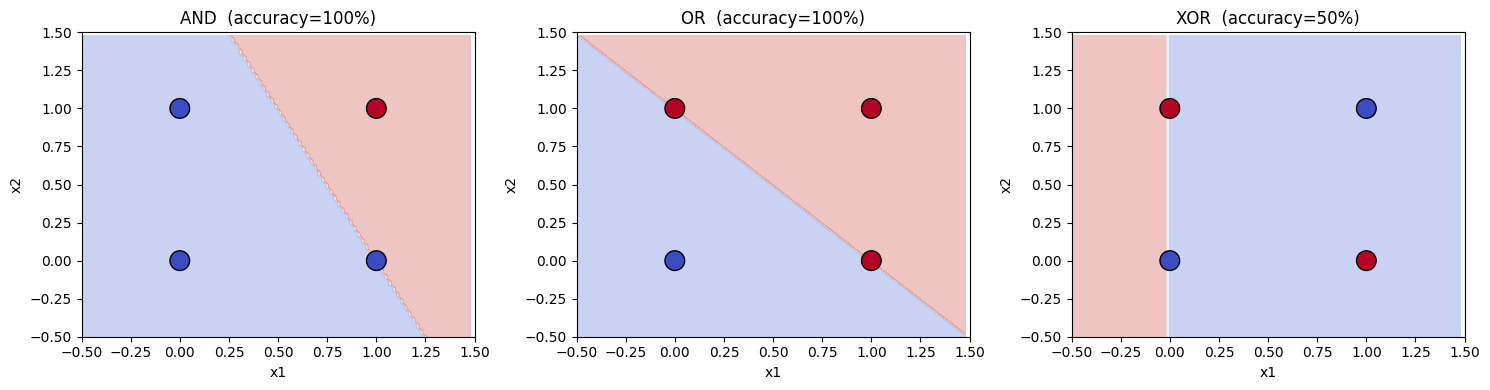

Notice: a single perceptron cannot solve XOR — its decision region
must be a single half-plane, but XOR's positive class is two opposite corners.


In [ ]:
def plot_decision_boundary(model, X, y, title, ax):
    h = 0.02
    xx, yy = np.meshgrid(np.arange(-0.5, 1.5, h),
                         np.arange(-0.5, 1.5, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm',
               edgecolors='k', s=200)
    ax.set_title(title); ax.set_xlabel("x1"); ax.set_ylabel("x2")
    ax.set_xlim(-0.5, 1.5); ax.set_ylim(-0.5, 1.5)

# AND, OR (linearly separable)  vs.  XOR (NOT linearly separable)
datasets = {
    "AND": (X_and, np.array([0,0,0,1])),
    "OR" : (X_and, np.array([0,1,1,1])),
    "XOR": (X_and, np.array([0,1,1,0]))
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, (X, y)) in zip(axes, datasets.items()):
    p = Perceptron(2, lr=0.1)
    hist = p.fit(X, y, epochs=50)
    acc = (p.predict(X) == y).mean()
    plot_decision_boundary(p, X, y, f"{name}  (accuracy={acc:.0%})", ax)
plt.tight_layout(); plt.show()

print("Notice: a single perceptron cannot solve XOR — its decision region")
print("must be a single half-plane, but XOR's positive class is two opposite corners.")


---
## 8. Solving XOR with a multilayer perceptron

If one neuron carves a single line through the input space, **two layers of neurons** can carve **regions of arbitrary complexity** by combining lines. Below we hand-craft an MLP for XOR with two hidden ReLU neurons. After this we'll **train** an MLP automatically.


In [ ]:
def relu(z):  return np.maximum(0, z)

# Hand-crafted weights that solve XOR
W1 = np.array([[ 1.0,  1.0],
               [ 1.0,  1.0]])
b1 = np.array([ 0.0, -1.0])
W2 = np.array([[ 1.0],
               [-2.0]])
b2 = np.array([0.0])

def xor_mlp(x):
    h = relu(x @ W1 + b1)
    return (h @ W2 + b2 >= 0.5).astype(int).ravel()

X_xor = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
y_xor = np.array([0,1,1,0])
print("Hand-crafted MLP predictions:", xor_mlp(X_xor))
print("Targets                     :", y_xor)


Hand-crafted MLP predictions: [0 1 1 0]
Targets                     : [0 1 1 0]


---
## 9. Multilayer perceptrons (MLPs)

### 9.1 Architecture

An MLP is a stack of **fully connected layers**:

$$
\mathbf{h}^{(1)} = \varphi(\mathbf{W}^{(1)} \mathbf{x} + \mathbf{b}^{(1)})
$$

$$
\mathbf{h}^{(\ell)} = \varphi(\mathbf{W}^{(\ell)} \mathbf{h}^{(\ell-1)} + \mathbf{b}^{(\ell)})
$$

$$
\hat{\mathbf{y}} = \varphi_\text{out}(\mathbf{W}^{(L)} \mathbf{h}^{(L-1)} + \mathbf{b}^{(L)})
$$

### 9.2 What are hidden layers?

Layers between input and output. Each hidden layer transforms its input into a representation more useful for the next layer. Through training the network discovers what those representations should be — this is **representation learning**.

### 9.3 How many layers? How many nodes?

There is no universally optimal answer; it depends on data and task. Practical guidance:

* **Universal Approximation Theorem** (Cybenko 1989, Hornik 1991): even *one* sufficiently-wide hidden layer with a non-linear activation can approximate any continuous function on a compact domain. So why use deep nets? Because **depth is exponentially more efficient** than width for many functions, and deep nets generalize better in practice.
* **Width** (nodes per layer) controls the capacity of each transformation.
* **Depth** (number of layers) controls the level of compositionality.
* Start with a baseline (e.g. 2–3 hidden layers, 64–512 units), then iterate based on training/validation curves.

### 9.4 Takeaways

* Stacking neurons enables non-linear decision boundaries.
* Activations between layers are essential — without them, an MLP collapses to a single linear map.
* Architecture choice is empirical; debug with learning curves.


---
## 10. Activation functions — a complete tour

Activation functions inject **non-linearity**. Without them, a stack of linear layers is just one giant linear layer. We will look at every common activation, plot it next to its derivative, and discuss when to use it.


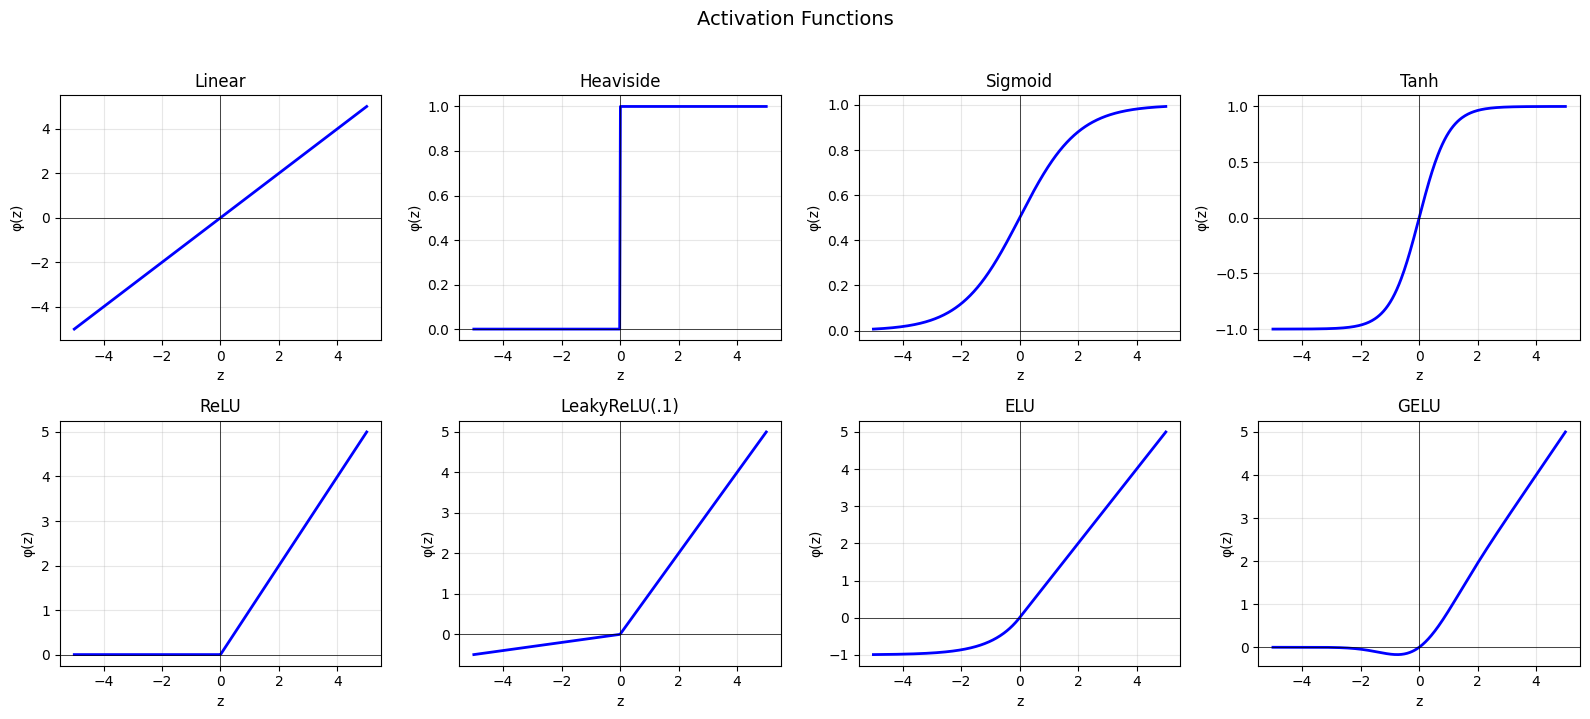

In [ ]:
# Define activations and their derivatives
z = torch.linspace(-5, 5, 400)

def linear(z):    return z
def heaviside(z): return (z >= 0).float()
def sigmoid(z):   return 1 / (1 + torch.exp(-z))
def tanh(z):      return torch.tanh(z)
def relu(z):      return torch.clamp(z, min=0)
def leaky_relu(z, a=0.1): return torch.where(z > 0, z, a * z)
def elu(z, a=1.0): return torch.where(z > 0, z, a*(torch.exp(z) - 1))
def gelu(z):      return 0.5 * z * (1 + torch.tanh(np.sqrt(2/np.pi) * (z + 0.044715 * z**3)))

acts = {
    "Linear"      : linear,
    "Heaviside"   : heaviside,
    "Sigmoid"     : sigmoid,
    "Tanh"        : tanh,
    "ReLU"        : relu,
    "LeakyReLU(.1)": leaky_relu,
    "ELU"         : elu,
    "GELU"        : gelu,
}

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, (name, f) in zip(axes.ravel(), acts.items()):
    ax.plot(z.numpy(), f(z).numpy(), 'b-', lw=2, label=name)
    ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
    ax.grid(alpha=0.3); ax.set_title(name)
    ax.set_xlabel("z"); ax.set_ylabel("φ(z)")
plt.suptitle("Activation Functions", fontsize=14, y=1.02)
plt.tight_layout(); plt.show()


### 10.1 Linear (identity) — `φ(z) = z`

Used **only** at the output of regression networks. If used everywhere, the entire network is linear (useless for non-linear tasks).

### 10.2 Heaviside step — `φ(z) = 1{z≥0}`

The classical perceptron activation. It is **non-differentiable** at 0 and has zero gradient elsewhere, which kills backprop. **Never used in deep networks today.**

### 10.3 Sigmoid / logistic — `φ(z) = 1/(1+e⁻ᶻ)`

Smooth, output ∈ (0, 1). Historically very popular. Two big drawbacks:
* **Vanishing gradient**: derivative is tiny at large |z| (saturation), so deep nets stop learning.
* **Not zero-centered**: outputs always positive, slowing optimization.

Today used mainly at the **output layer of binary classifiers** (interpreted as P(y=1)).

### 10.4 Softmax — output activation for multi-class

For C classes:

$$
\text{softmax}(z)_i = \frac{e^{z_i}}{\sum_{j=1}^{C} e^{z_j}}
$$

It produces a probability distribution over classes. Always pair it with **cross-entropy loss**.

### 10.5 Tanh — `φ(z) = (eᶻ-e⁻ᶻ)/(eᶻ+e⁻ᶻ)`

Zero-centered version of sigmoid, output ∈ (-1, 1). Better than sigmoid for hidden layers but still saturates.

### 10.6 ReLU — `φ(z) = max(0, z)`

The current default for hidden layers. Cheap (one comparison), no upper saturation, sparse activations.
* **Pro:** dramatically improves training speed and depth.
* **Con: "dying ReLU"** — neurons can get stuck outputting 0 with zero gradient forever.

### 10.7 Leaky ReLU — `φ(z) = z if z>0 else αz`

Adds a small slope (e.g. α=0.01 or 0.1) for z<0 to keep gradient alive — fixes the dying-ReLU problem.

### 10.8 Beyond the listed ones (worth knowing)

* **ELU** — smooth, negative values bring mean activation closer to 0.
* **GELU** — used in Transformers (BERT, GPT). Smooth approximation of ReLU.
* **SiLU/Swish** — `z·sigmoid(z)`, used in EfficientNet.
* **Softplus** — smooth approximation of ReLU.


In [ ]:
# Quick numeric demo — softmax
logits = torch.tensor([2.0, 1.0, 0.1])
probs  = F.softmax(logits, dim=0)
print(f"logits     : {logits.tolist()}")
print(f"softmax    : {probs.tolist()}  (sum={probs.sum().item():.4f})")
print(f"log-softmax: {F.log_softmax(logits, dim=0).tolist()}")


logits     : [2.0, 1.0, 0.10000000149011612]
softmax    : [0.6590011715888977, 0.24243298172950745, 0.09856589138507843]  (sum=1.0000)
log-softmax: [-0.4170299470424652, -1.4170299768447876, -2.3170299530029297]


### 10.9 Output-layer activation — choose by task

| Task                       | Output activation | Loss                     |
|----------------------------|-------------------|--------------------------|
| Regression                 | Linear (none)     | MSE / Huber              |
| Binary classification      | Sigmoid           | Binary cross-entropy     |
| Multi-class (single label) | Softmax           | Categorical cross-entropy|
| Multi-label (multiple)     | Sigmoid per node  | Binary cross-entropy     |


---
## 11. The feedforward process

**Feedforward** simply means: starting from the input, compute the activations of each layer in order until you reach the output. There is no notion of learning here — only inference.

For an L-layer MLP:

$$
\mathbf{a}^{(0)} = \mathbf{x}
$$

$$
\mathbf{z}^{(\ell)} = \mathbf{W}^{(\ell)}\mathbf{a}^{(\ell-1)} + \mathbf{b}^{(\ell)},\qquad
\mathbf{a}^{(\ell)} = \varphi(\mathbf{z}^{(\ell)}),\qquad \ell=1,\dots,L
$$

$$
\hat{\mathbf{y}} = \mathbf{a}^{(L)}
$$

### Feature learning

Each hidden layer can be viewed as computing **learned features** of the input. Early layers tend to capture simple, generic patterns; deeper layers compose them into task-specific concepts. This emergent hierarchy is the central reason deep learning is so effective on raw data (pixels, audio, text).


In [ ]:
# Manual feedforward of a tiny MLP — purely with tensors, to see the math
torch.manual_seed(0)
x = torch.tensor([0.5, -1.2, 3.1])    # 3-dim input

# Layer 1: 3 -> 4
W1 = torch.randn(4, 3) * 0.5
b1 = torch.zeros(4)
# Layer 2: 4 -> 2 (binary classification)
W2 = torch.randn(2, 4) * 0.5
b2 = torch.zeros(2)

# Forward pass
z1 = W1 @ x + b1
a1 = torch.relu(z1)
z2 = W2 @ a1 + b2
y_hat = F.softmax(z2, dim=0)

print("Input x          :", x.tolist())
print("Pre-activation z1:", z1.tolist())
print("Hidden a1 (ReLU) :", a1.tolist())
print("Pre-activation z2:", z2.tolist())
print("Output (softmax) :", y_hat.tolist(),
      "  -> sum =", y_hat.sum().item())


Input x          : [0.5, -1.2000000476837158, 3.0999999046325684]
Pre-activation z1: [-2.815816879272461, -1.3750015497207642, -1.5168282985687256, 0.539301872253418]
Hidden a1 (ReLU) : [0.0, 0.0, 0.0, 0.539301872253418]
Pre-activation z2: [0.03308650478720665, -0.4069322943687439]
Output (softmax) : [0.6082634925842285, 0.3917364776134491]   -> sum = 1.0


---
## 12. Error (loss) functions

### 12.1 What is an error function?

A scalar function **L(y, ŷ)** that measures the gap between predictions and targets. **Training = minimize L by adjusting weights.**

### 12.2 Why must we have one?

Optimization needs a measurable objective. Accuracy alone is not differentiable, so we use a smooth surrogate.

### 12.3 Why must error be positive?

A signed error would let positive and negative errors **cancel out** when averaged. We square or take negative log probabilities to make every individual error contribute positively to the total.

### 12.4 Mean Squared Error (MSE) — for regression

$$
\mathcal{L}_\text{MSE} = \frac{1}{N}\sum_{i=1}^{N}(y_i - \hat y_i)^2
$$

* Smooth, convex (in ŷ), strongly penalizes large errors.
* Use with **linear** output activation.

### 12.5 Cross-Entropy (CE) — for classification

For C classes (single-label) with one-hot target y and softmax prediction p:

$$
\mathcal{L}_\text{CE} = -\sum_{i=1}^{N}\sum_{c=1}^{C} y_{i,c}\,\log p_{i,c}
$$

* Equivalent to maximum likelihood under a categorical distribution.
* Penalizes confident wrong predictions very strongly.
* PyTorch: `nn.CrossEntropyLoss` expects **raw logits** (it applies log-softmax internally — numerically stable). **Do not** apply softmax before this loss!

### 12.6 Other losses you'll meet

* **Binary cross-entropy** (`BCEWithLogitsLoss`) — for binary / multi-label tasks.
* **MAE / L1** — robust to outliers.
* **Huber / Smooth L1** — quadratic near 0, linear far away.
* **Hinge loss** — SVMs.
* **KL divergence** — distribution matching, distillation.

### 12.7 A final note on errors and weights

The loss is a function of the **weights**. Visualizing it as a "loss surface" over weight space gives the intuition behind gradient descent: roll downhill.


In [ ]:
# Illustration — MSE vs MAE on a simple regression
y_true = torch.tensor([1.0, 2.0, 3.0, 4.0, 5.0])
y_pred = torch.tensor([1.1, 2.0, 2.9, 4.5, 8.0])  # last one is an outlier

mse = F.mse_loss(y_pred, y_true)
mae = F.l1_loss(y_pred, y_true)
print(f"MSE = {mse.item():.4f}   (squares the outlier — large)")
print(f"MAE = {mae.item():.4f}   (less sensitive to outliers)")

# Cross-entropy demonstration
logits = torch.tensor([[2.0, 0.5, 0.1],     # sample 1: predicts class 0
                       [0.1, 0.2, 3.0]])    # sample 2: predicts class 2
targets = torch.tensor([0, 2])              # both correct -> low loss
loss_correct = F.cross_entropy(logits, targets)

targets_wrong = torch.tensor([1, 1])        # both wrong  -> high loss
loss_wrong   = F.cross_entropy(logits, targets_wrong)
print(f"\nCE (correct preds): {loss_correct.item():.4f}")
print(f"CE (wrong   preds): {loss_wrong.item():.4f}")


MSE = 1.8540   (squares the outlier — large)
MAE = 0.7400   (less sensitive to outliers)

CE (correct preds): 0.2132
CE (wrong   preds): 2.3632


---
## 13. Optimization algorithms

### 13.1 What is optimization?

Finding parameters **θ\*** that minimize the loss:
$$\theta^* = \arg\min_\theta \mathcal{L}(\theta)$$
For linear/convex problems we have closed-form solutions; neural networks are **non-convex**, so we use iterative methods, mostly **gradient descent**.

### 13.2 Gradient descent — the universal recipe

$$
\theta_{t+1} = \theta_t - \eta\,\nabla_\theta \mathcal{L}(\theta_t)
$$

where η is the **learning rate**. Three flavours, depending on how much data is used per update:

| Flavour                   | Data per update | Pros                             | Cons                           |
|---------------------------|-----------------|----------------------------------|--------------------------------|
| **Batch GD**              | All N examples  | Smooth, accurate gradient        | Slow per step; doesn't fit GPU memory for big data |
| **Stochastic GD (SGD)**   | 1 example       | Fast updates; can escape minima  | Noisy; underutilizes hardware  |
| **Mini-batch GD** (used everywhere) | k examples (e.g. 32–512) | Good balance: smooth-ish, fast, GPU-friendly | Need to tune batch size       |

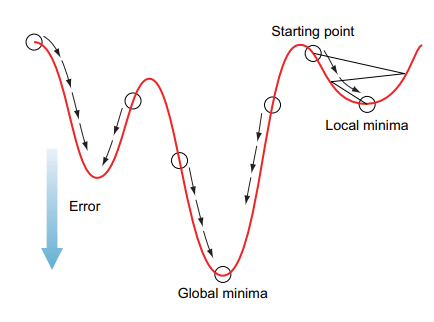

### 13.3 Beyond plain SGD

* **Momentum** — accumulates an exponentially-decayed average of past gradients, dampens oscillations.
* **Nesterov** — momentum with look-ahead.
* **AdaGrad** — per-parameter adaptive lr (decays).
* **RMSProp** — running mean of squared grads; good for non-stationary objectives.
* **Adam** — momentum + RMSProp; current default optimizer for many tasks.
* **AdamW** — Adam with **decoupled** weight decay; preferred over Adam for regularized training.

### 13.4 Takeaways

* The learning rate η is the single most important hyperparameter.
* Mini-batch SGD with momentum / AdamW is the modern workhorse.
* Adaptive optimizers (Adam) often work well out of the box but generalize slightly worse on some vision tasks than well-tuned SGD+momentum.

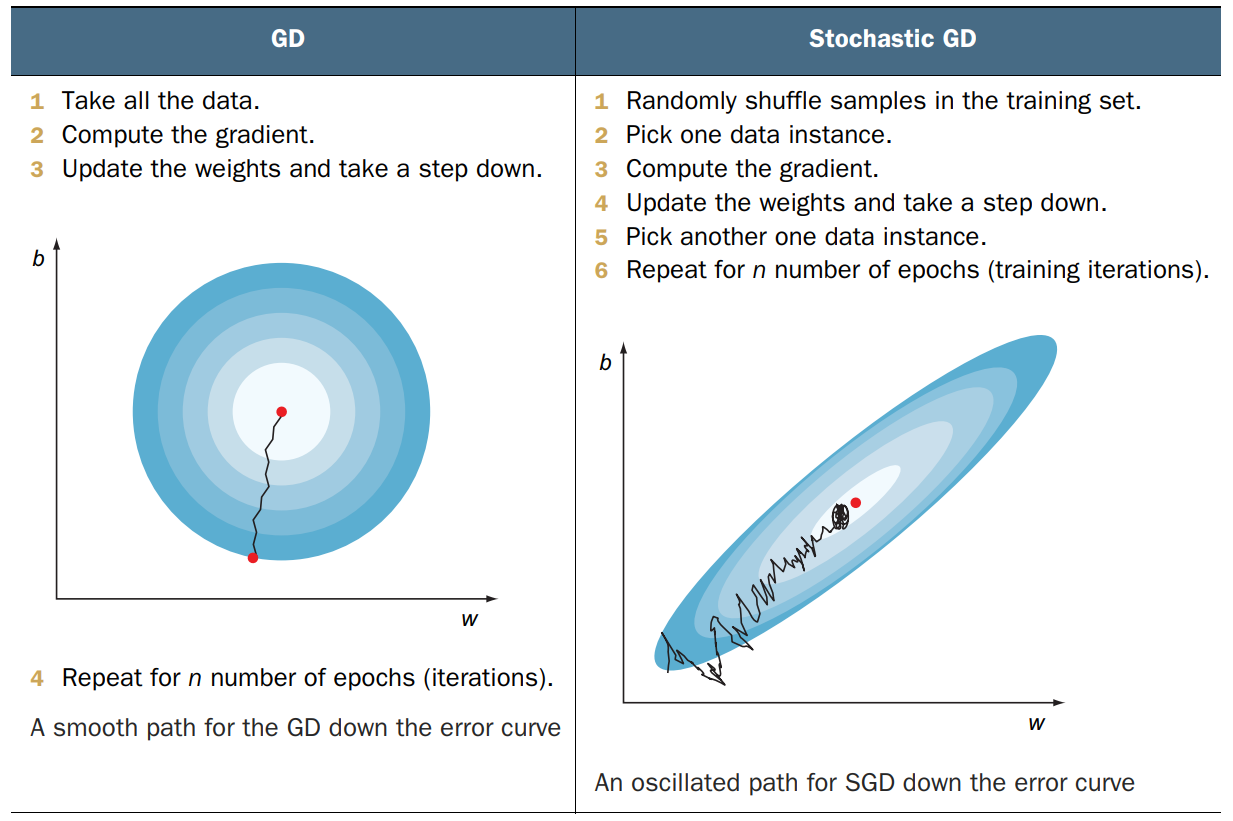

---
## 14. Backpropagation — the chain rule, in matrix form

We need ∂L/∂W for each weight matrix W. Computing them naïvely (one weight at a time) is intractable. **Backpropagation** does this efficiently in a single backward pass through the network.

### Setup

For a layer ℓ with input **a^(ℓ-1)**, weights **W^(ℓ)**, bias **b^(ℓ)**:
$$
\mathbf{z}^{(\ell)} = \mathbf{W}^{(\ell)}\mathbf{a}^{(\ell-1)} + \mathbf{b}^{(\ell)},\quad
\mathbf{a}^{(\ell)} = \varphi(\mathbf{z}^{(\ell)})
$$

Define the **error signal** at layer ℓ:
$$
\boldsymbol{\delta}^{(\ell)} = \frac{\partial \mathcal{L}}{\partial \mathbf{z}^{(\ell)}}
$$

### The four equations of backpropagation

1. **Output layer:** δ^(L) = ∇_a L ⊙ φ'(z^(L)).
2. **Backward recursion:** δ^(ℓ) = ((W^(ℓ+1))ᵀ δ^(ℓ+1)) ⊙ φ'(z^(ℓ)).
3. **Bias gradients:** ∂L/∂b^(ℓ) = δ^(ℓ).
4. **Weight gradients:** ∂L/∂W^(ℓ) = δ^(ℓ) (a^(ℓ-1))ᵀ.

### Backpropagation takeaways

* It's just the chain rule, applied systematically backwards.
* Cost is roughly the same as one forward pass — that's why training is feasible.
* In PyTorch, **autograd does this automatically**. You write the forward, call `.backward()`, done.

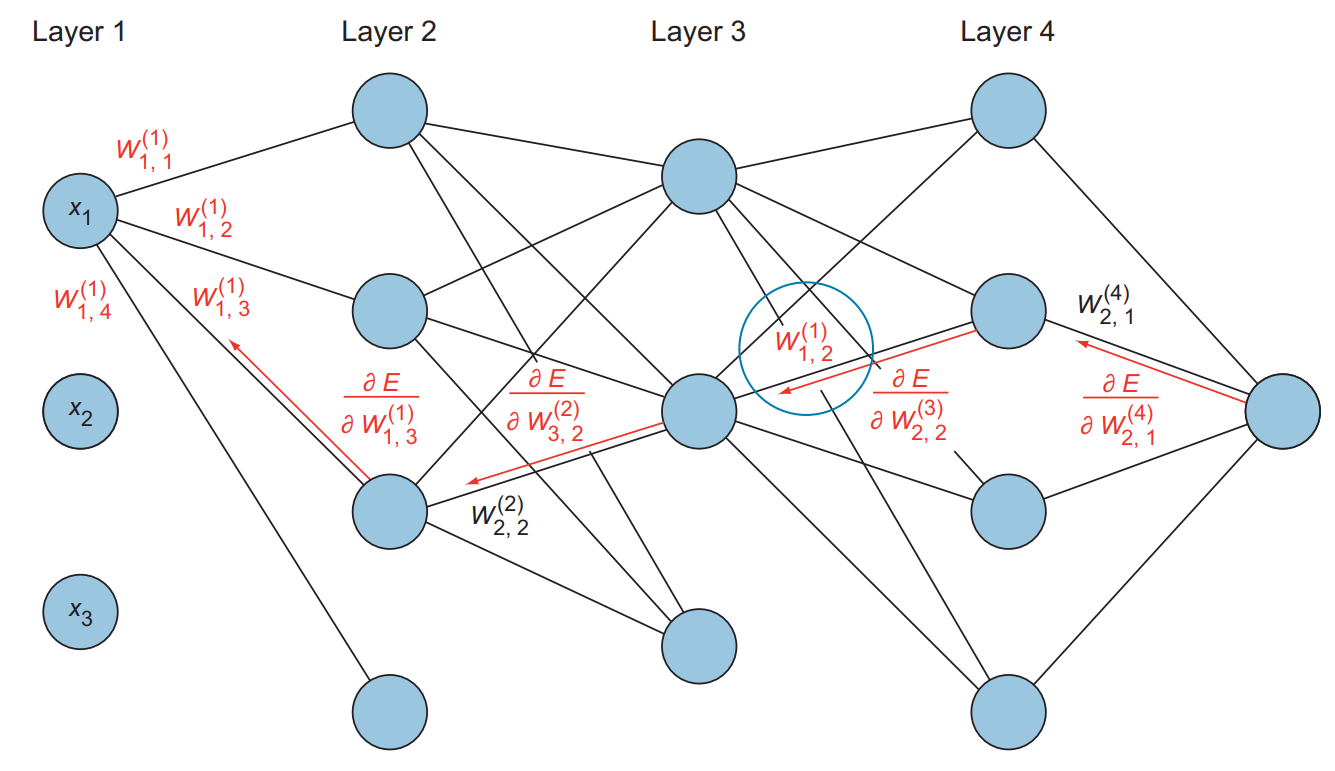

### Implementing backprop manually

To make this concrete, we implement a 2-layer network from scratch in NumPy and check the gradients against PyTorch's autograd.


In [ ]:
# A 2-layer MLP from scratch — forward + manual backprop
np.random.seed(0)
N, D_in, H, D_out = 64, 8, 32, 4

X  = np.random.randn(N, D_in)
y  = np.random.randint(0, D_out, size=N)
Y  = np.eye(D_out)[y]                          # one-hot targets

# Initialize weights (He init -- discussed later)
W1 = np.random.randn(D_in, H) * np.sqrt(2.0 / D_in)
b1 = np.zeros(H)
W2 = np.random.randn(H, D_out) * np.sqrt(2.0 / H)
b2 = np.zeros(D_out)

def softmax(z):
    z = z - z.max(axis=1, keepdims=True)        # numerical stability
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)

def forward(X):
    z1 = X @ W1 + b1
    a1 = np.maximum(0, z1)                      # ReLU
    z2 = a1 @ W2 + b2
    p  = softmax(z2)
    return z1, a1, z2, p

def cross_entropy(p, Y):
    return -np.mean(np.sum(Y * np.log(p + 1e-12), axis=1))

def backward(X, Y, z1, a1, z2, p):
    N = X.shape[0]
    # output layer: dL/dz2 = p - Y     (softmax + cross-entropy combined)
    dz2 = (p - Y) / N
    dW2 = a1.T @ dz2
    db2 = dz2.sum(axis=0)

    da1 = dz2 @ W2.T
    dz1 = da1 * (z1 > 0)                        # ReLU'(z) = 1{z>0}
    dW1 = X.T @ dz1
    db1 = dz1.sum(axis=0)
    return dW1, db1, dW2, db2

# One training step
lr = 1e-1
for step in range(2001):
    z1, a1, z2, p = forward(X)
    loss = cross_entropy(p, Y)
    dW1, db1, dW2, db2 = backward(X, Y, z1, a1, z2, p)
    W1 -= lr * dW1; b1 -= lr * db1
    W2 -= lr * dW2; b2 -= lr * db2
    if step % 400 == 0:
        acc = (p.argmax(1) == y).mean()
        print(f"step {step:4d}  loss={loss:.4f}  acc={acc:.2%}")


step    0  loss=1.5915  acc=37.50%
step  400  loss=0.2912  acc=96.88%
step  800  loss=0.1024  acc=100.00%
step 1200  loss=0.0492  acc=100.00%
step 1600  loss=0.0296  acc=100.00%
step 2000  loss=0.0203  acc=100.00%


**Sanity-check our hand-derived gradients against PyTorch autograd** — a great debugging trick to know.

In [ ]:
# Compare manual gradient with PyTorch autograd for a single example
torch.manual_seed(0)
x_t  = torch.tensor(X[:4], dtype=torch.float64, requires_grad=False)
W1_t = torch.tensor(W1,    dtype=torch.float64, requires_grad=True)
b1_t = torch.tensor(b1,    dtype=torch.float64, requires_grad=True)
W2_t = torch.tensor(W2,    dtype=torch.float64, requires_grad=True)
b2_t = torch.tensor(b2,    dtype=torch.float64, requires_grad=True)
y_t  = torch.tensor(y[:4], dtype=torch.long)

logits = torch.relu(x_t @ W1_t + b1_t) @ W2_t + b2_t
loss_t = F.cross_entropy(logits, y_t)
loss_t.backward()

# manual backward on the same 4 examples
z1m, a1m, z2m, pm = forward(X[:4])
dW1m, db1m, dW2m, db2m = backward(X[:4], np.eye(D_out)[y[:4]],
                                  z1m, a1m, z2m, pm)

print("Max |W1 grad diff|:", np.max(np.abs(W1_t.grad.numpy() - dW1m)))
print("Max |W2 grad diff|:", np.max(np.abs(W2_t.grad.numpy() - dW2m)))
print("\n(The differences should be ~1e-15 -- machine precision.)")


Max |W1 grad diff|: 1.0625181290357943e-17
Max |W2 grad diff|: 1.5612511283791264e-17

(The differences should be ~1e-15 -- machine precision.)


---
# Part 3 — Building Real Neural Networks in PyTorch

Now we use PyTorch's high-level API to build, train, and analyze MLPs on real datasets — focusing on the *engineering* that makes deep learning actually work.

---
## 15. `torch.nn` and the `nn.Module` API

PyTorch organizes networks as subclasses of `nn.Module`. The framework keeps track of all parameters automatically, exposes them via `.parameters()`, and lets you move / save / load the whole model in one line.


In [ ]:
class TinyMLP(nn.Module):
    # A 2-layer MLP for binary classification.
    def __init__(self, in_features, hidden, out_features):
        super().__init__()
        self.fc1 = nn.Linear(in_features, hidden)
        self.fc2 = nn.Linear(hidden,      out_features)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = TinyMLP(in_features=2, hidden=8, out_features=2)
print(model)
print("\nNumber of parameters:", sum(p.numel() for p in model.parameters()))
for name, p in model.named_parameters():
    print(f"  {name:12s}  shape={tuple(p.shape)}  requires_grad={p.requires_grad}")


TinyMLP(
  (fc1): Linear(in_features=2, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=2, bias=True)
)

Number of parameters: 42
  fc1.weight    shape=(8, 2)  requires_grad=True
  fc1.bias      shape=(8,)  requires_grad=True
  fc2.weight    shape=(2, 8)  requires_grad=True
  fc2.bias      shape=(2,)  requires_grad=True


### Training the MLP on XOR with PyTorch

This is the smallest possible end-to-end PyTorch training loop. The same skeleton scales to ResNets, Transformers, etc.


Final loss: 0.000481
Predictions: [0, 1, 1, 0]   targets: [0, 1, 1, 0]


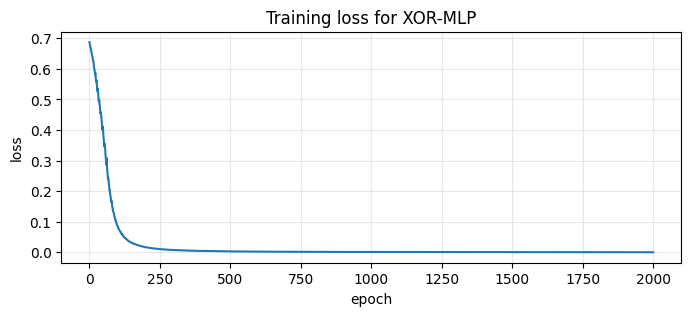

In [ ]:
set_seed(0)
X = torch.tensor([[0,0],[0,1],[1,0],[1,1]], dtype=torch.float32)
y = torch.tensor([0, 1, 1, 0], dtype=torch.long)

model     = TinyMLP(2, 8, 2)
optimizer = optim.SGD(model.parameters(), lr=0.5)
loss_fn   = nn.CrossEntropyLoss()

losses = []
for epoch in range(2000):
    optimizer.zero_grad()           # 1) clear old gradients
    logits = model(X)               # 2) forward
    loss   = loss_fn(logits, y)     # 3) compute loss
    loss.backward()                 # 4) backward (autograd)
    optimizer.step()                # 5) update weights
    losses.append(loss.item())

print(f"Final loss: {losses[-1]:.6f}")
preds = model(X).argmax(dim=1)
print(f"Predictions: {preds.tolist()}   targets: {y.tolist()}")

plt.figure(figsize=(8,3))
plt.plot(losses); plt.xlabel("epoch"); plt.ylabel("loss")
plt.title("Training loss for XOR-MLP"); plt.grid(alpha=0.3); plt.show()


**Visualize the non-linear decision boundary** the MLP learned — compare with the perceptron's straight line!

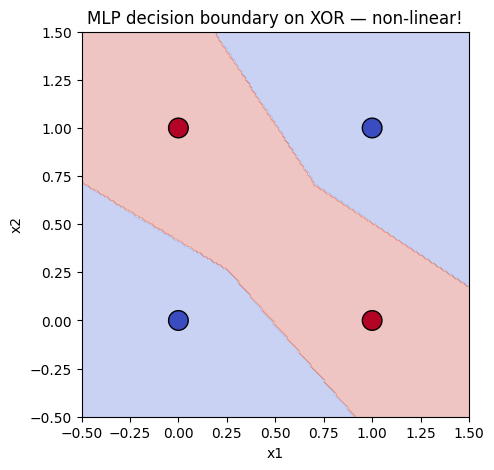

In [ ]:
xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 200),
                     np.linspace(-0.5, 1.5, 200))
grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
with torch.no_grad():
    Z = model(grid).argmax(dim=1).numpy().reshape(xx.shape)

plt.figure(figsize=(5,5))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm', edgecolors='k', s=200)
plt.title("MLP decision boundary on XOR — non-linear!")
plt.xlabel("x1"); plt.ylabel("x2"); plt.show()


---
## 16. Datasets and `DataLoader`

For real problems, data doesn't fit in a single tensor. PyTorch separates **what is the data** (`Dataset`) from **how it is iterated** (`DataLoader`).

* `Dataset` — defines `__len__` and `__getitem__`.
* `DataLoader` — handles batching, shuffling, parallel loading, pinning to GPU memory.

Below we use `torchvision`'s built-in **Fashion-MNIST** dataset (auto-downloaded, no upload needed).


In [ ]:
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader, random_split

# Compose transforms: convert PIL -> tensor in [0,1], then normalize
transform = transforms.Compose([
    transforms.ToTensor(),                     # (H,W) PIL -> (1,H,W) float in [0,1]
    transforms.Normalize((0.2860,), (0.3530,)) # standard FashionMNIST mean/std
])

train_full = torchvision.datasets.FashionMNIST(
    root="./data", train=True,  download=True, transform=transform)
test_set   = torchvision.datasets.FashionMNIST(
    root="./data", train=False, download=True, transform=transform)

# Carve out a validation set so we can monitor over-fitting
train_set, val_set = random_split(train_full, [54_000, 6_000],
                                  generator=torch.Generator().manual_seed(42))

print(f"Train: {len(train_set)},   Val: {len(val_set)},   Test: {len(test_set)}")
print(f"Each example: {train_set[0][0].shape}  label={train_set[0][1]}")

class_names = ["T-shirt/top","Trouser","Pullover","Dress","Coat",
               "Sandal","Shirt","Sneaker","Bag","Ankle boot"]


100%|██████████| 26.4M/26.4M [00:02<00:00, 12.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 216kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.97MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 25.3MB/s]

Train: 54000,   Val: 6000,   Test: 10000
Each example: torch.Size([1, 28, 28])  label=9


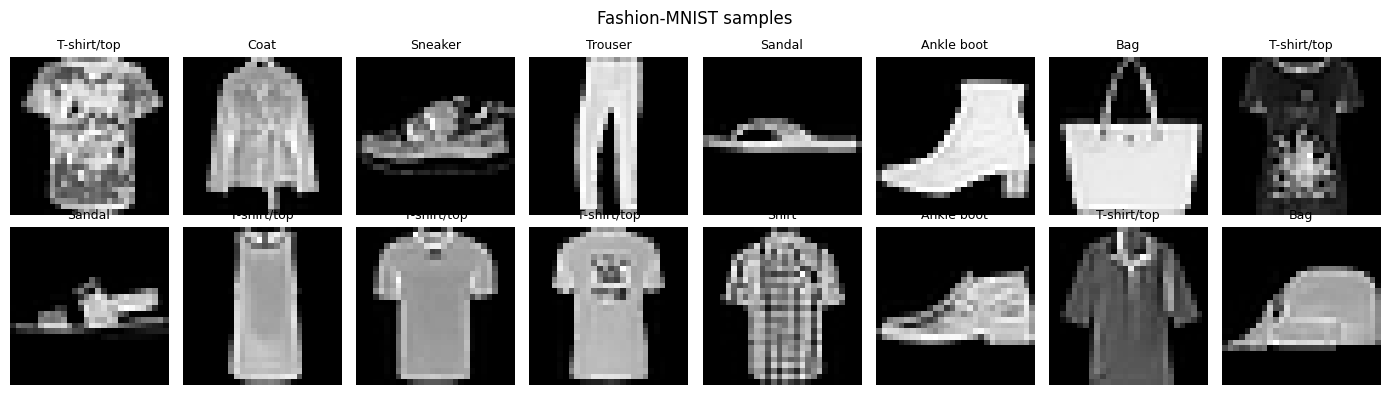

In [ ]:
# Visualize a few samples
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for ax, idx in zip(axes.ravel(), np.random.choice(len(train_set), 16, replace=False)):
    img, lbl = train_set[idx]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(class_names[lbl], fontsize=9)
    ax.axis('off')
plt.suptitle("Fashion-MNIST samples"); plt.tight_layout(); plt.show()


In [ ]:
# DataLoaders
BATCH = 128
train_loader = DataLoader(train_set, batch_size=BATCH, shuffle=True,
                          num_workers=2, pin_memory=torch.cuda.is_available())
val_loader   = DataLoader(val_set,   batch_size=BATCH, shuffle=False,
                          num_workers=2, pin_memory=torch.cuda.is_available())
test_loader  = DataLoader(test_set,  batch_size=BATCH, shuffle=False,
                          num_workers=2, pin_memory=torch.cuda.is_available())

# Inspect a batch
xb, yb = next(iter(train_loader))
print(f"Batch shape: {xb.shape}   labels shape: {yb.shape}")
print(f"x range: [{xb.min():.3f}, {xb.max():.3f}]   dtype={xb.dtype}")


Batch shape: torch.Size([128, 1, 28, 28])   labels shape: torch.Size([128])
x range: [-0.810, 2.023]   dtype=torch.float32


---
## 17. Reusable training and evaluation functions

Below is the **canonical PyTorch training loop**. Memorize this pattern — almost every experiment in this notebook uses it.


In [ ]:
@torch.no_grad()
def evaluate(model, loader, loss_fn, device):
    model.eval()
    total, correct, loss_sum = 0, 0, 0.0
    for xb, yb in loader:
        xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
        logits = model(xb)
        loss   = loss_fn(logits, yb)
        loss_sum += loss.item() * xb.size(0)
        correct  += (logits.argmax(1) == yb).sum().item()
        total    += xb.size(0)
    return loss_sum / total, correct / total


def train(model, train_loader, val_loader, *, epochs, optimizer,
          loss_fn=None, scheduler=None, device=device, verbose=True):
    if loss_fn is None: loss_fn = nn.CrossEntropyLoss()
    model.to(device)
    history = {"train_loss": [], "train_acc": [],
               "val_loss":   [], "val_acc":   []}

    for epoch in range(1, epochs + 1):
        model.train()
        run_loss, run_correct, run_total = 0.0, 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
            optimizer.zero_grad()
            logits = model(xb)
            loss   = loss_fn(logits, yb)
            loss.backward()
            optimizer.step()

            run_loss    += loss.item() * xb.size(0)
            run_correct += (logits.argmax(1) == yb).sum().item()
            run_total   += xb.size(0)

        if scheduler is not None:
            scheduler.step()

        train_loss = run_loss / run_total
        train_acc  = run_correct / run_total
        val_loss, val_acc = evaluate(model, val_loader, loss_fn, device)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if verbose:
            print(f"epoch {epoch:3d}/{epochs}  "
                  f"train: loss={train_loss:.4f} acc={train_acc:.4f}  "
                  f"val: loss={val_loss:.4f} acc={val_acc:.4f}")
    return history


def plot_history(histories, title=""):
    # `histories` is a dict[name -> history-dict] for side-by-side plotting.
    if isinstance(histories, dict) and "train_loss" in histories:
        histories = {"model": histories}
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for name, h in histories.items():
        axes[0].plot(h["train_loss"], label=f"{name} train")
        axes[0].plot(h["val_loss"],  '--', label=f"{name} val")
        axes[1].plot(h["train_acc"], label=f"{name} train")
        axes[1].plot(h["val_acc"],  '--', label=f"{name} val")
    axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss");     axes[0].set_title("Loss")
    axes[1].set_xlabel("epoch"); axes[1].set_ylabel("accuracy"); axes[1].set_title("Accuracy")
    for ax in axes: ax.legend(); ax.grid(alpha=0.3)
    plt.suptitle(title); plt.tight_layout(); plt.show()


---
## 18. A complete MLP for image classification

The input is a 28×28 grayscale image (784 pixels). The MLP flattens it and feeds it through 2 hidden layers.

> **Why use an MLP for images at all?** It's the wrong tool — it ignores spatial structure (we'll fix this with CNNs next module) — but it's a great pedagogical baseline.


In [ ]:
class MLPClassifier(nn.Module):
    def __init__(self, in_features=28*28, hidden=(256, 128), n_classes=10,
                 activation="relu", p_drop=0.0, use_bn=False):
        super().__init__()
        act = {"relu": nn.ReLU, "tanh": nn.Tanh,
               "sigmoid": nn.Sigmoid, "leaky_relu": nn.LeakyReLU}[activation]
        layers = [nn.Flatten()]
        prev = in_features
        for h in hidden:
            layers.append(nn.Linear(prev, h))
            if use_bn:           layers.append(nn.BatchNorm1d(h))
            layers.append(act())
            if p_drop > 0:       layers.append(nn.Dropout(p_drop))
            prev = h
        layers.append(nn.Linear(prev, n_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

baseline = MLPClassifier(hidden=(256, 128)).to(device)
print(baseline)
print("Params:", sum(p.numel() for p in baseline.parameters()))


MLPClassifier(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=10, bias=True)
  )
)
Params: 235146


epoch   1/8  train: loss=0.5399 acc=0.8048  val: loss=0.4559 acc=0.8340
epoch   2/8  train: loss=0.3841 acc=0.8600  val: loss=0.3819 acc=0.8598
epoch   3/8  train: loss=0.3502 acc=0.8727  val: loss=0.3820 acc=0.8672
epoch   4/8  train: loss=0.3352 acc=0.8752  val: loss=0.3715 acc=0.8633
epoch   5/8  train: loss=0.3177 acc=0.8838  val: loss=0.3626 acc=0.8718
epoch   6/8  train: loss=0.2989 acc=0.8899  val: loss=0.3747 acc=0.8697
epoch   7/8  train: loss=0.2845 acc=0.8946  val: loss=0.3879 acc=0.8695
epoch   8/8  train: loss=0.2791 acc=0.8963  val: loss=0.4125 acc=0.8655

Test acc (baseline): 0.8597


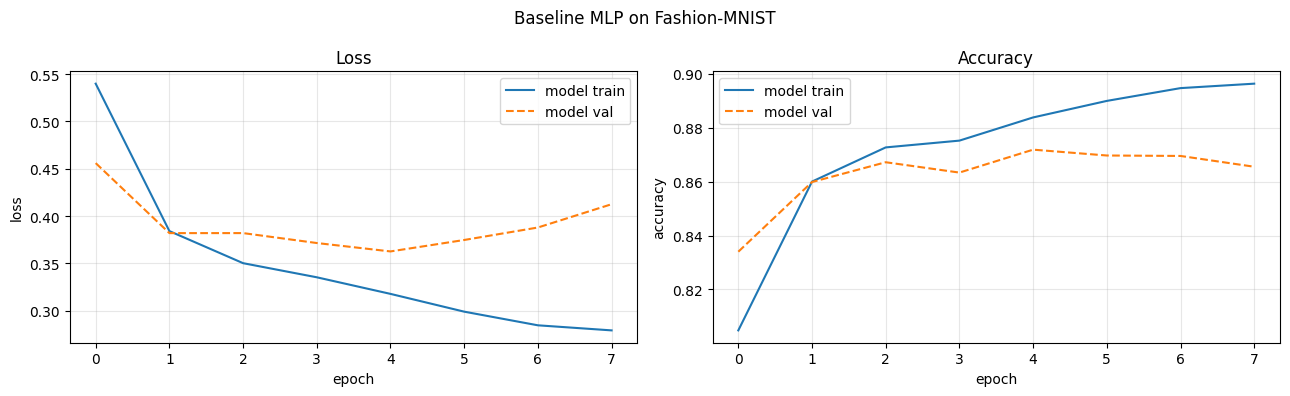

In [ ]:
# Train baseline MLP — small number of epochs to keep runtime modest
set_seed(0)
baseline   = MLPClassifier(hidden=(256, 128)).to(device)
optimizer  = optim.SGD(baseline.parameters(), lr=0.1, momentum=0.9)
EPOCHS     = 8

hist_base = train(baseline, train_loader, val_loader,
                  epochs=EPOCHS, optimizer=optimizer)

test_loss, test_acc = evaluate(baseline, test_loader, nn.CrossEntropyLoss(), device)
print(f"\nTest acc (baseline): {test_acc:.4f}")
plot_history(hist_base, title="Baseline MLP on Fashion-MNIST")


### Inspect predictions and the confusion matrix

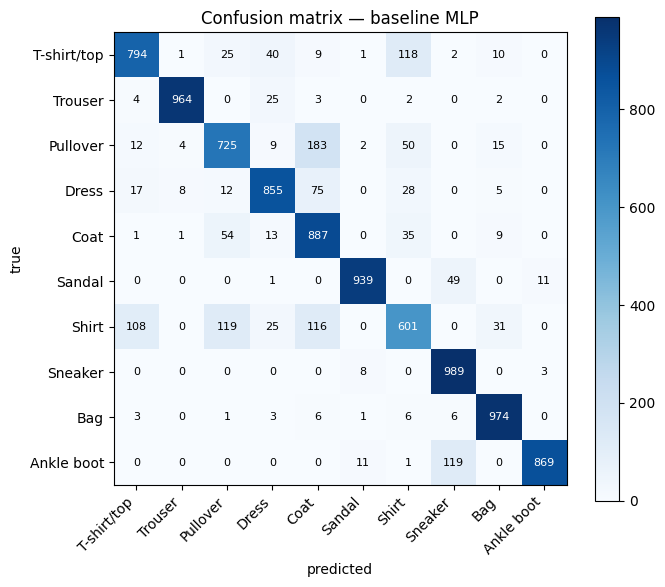

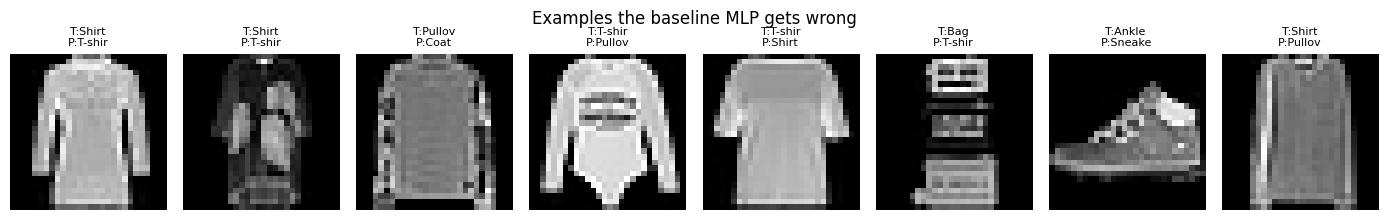

In [ ]:
# Confusion matrix on test set
@torch.no_grad()
def predictions(model, loader, device):
    model.eval()
    ys, yhats = [], []
    for xb, yb in loader:
        xb = xb.to(device)
        yhats.append(model(xb).argmax(1).cpu()); ys.append(yb)
    return torch.cat(ys).numpy(), torch.cat(yhats).numpy()

y_true, y_pred = predictions(baseline, test_loader, device)

cm = np.zeros((10, 10), int)
for t, p in zip(y_true, y_pred): cm[t, p] += 1

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.set_yticklabels(class_names)
ax.set_xlabel("predicted"); ax.set_ylabel("true")
for i in range(10):
    for j in range(10):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i,j] > cm.max()/2 else 'black', fontsize=8)
plt.title("Confusion matrix — baseline MLP"); plt.colorbar(im); plt.tight_layout(); plt.show()

# Show some mistakes
wrong = np.where(y_true != y_pred)[0]
sel = np.random.choice(wrong, 8, replace=False)
fig, axes = plt.subplots(1, 8, figsize=(14, 2.2))
for ax, idx in zip(axes, sel):
    img, _ = test_set[idx]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f"T:{class_names[y_true[idx]][:6]}\nP:{class_names[y_pred[idx]][:6]}",
                 fontsize=8); ax.axis('off')
plt.suptitle("Examples the baseline MLP gets wrong"); plt.tight_layout(); plt.show()


---
## 19. Regularization — fighting over-fitting

A high-capacity network can memorize the training set perfectly while failing on new data. **Regularization** = any technique that improves generalization.

### 19.1 Weight decay (L2)

Adds `λ ∑ w²` to the loss → shrinks weights → smoother functions. In PyTorch, set `weight_decay=λ` in the optimizer.

### 19.2 Dropout

During training, randomly zero each unit's output with probability *p*. At test time, all units are kept. This forces the network to develop redundant, robust features. Use `nn.Dropout(p)`.

### 19.3 Batch normalization (BN)

Normalizes each layer's pre-activations within a mini-batch (mean 0, variance 1), then re-scales/re-shifts with learned γ, β. Greatly stabilizes training, often allows higher lr, and acts as a mild regularizer.

### 19.4 Data augmentation

Generate "free" training data by random transformations (flip, crop, rotate). Especially powerful for vision; we'll lean on it heavily for CNNs.

### 19.5 Early stopping

Monitor validation loss; stop when it plateaus or worsens.

Below we compare **no regularization vs dropout vs batch-norm**.


--- training plain ---
   test acc = 0.8615
--- training dropout ---
   test acc = 0.8357
--- training batchnorm ---
   test acc = 0.8819


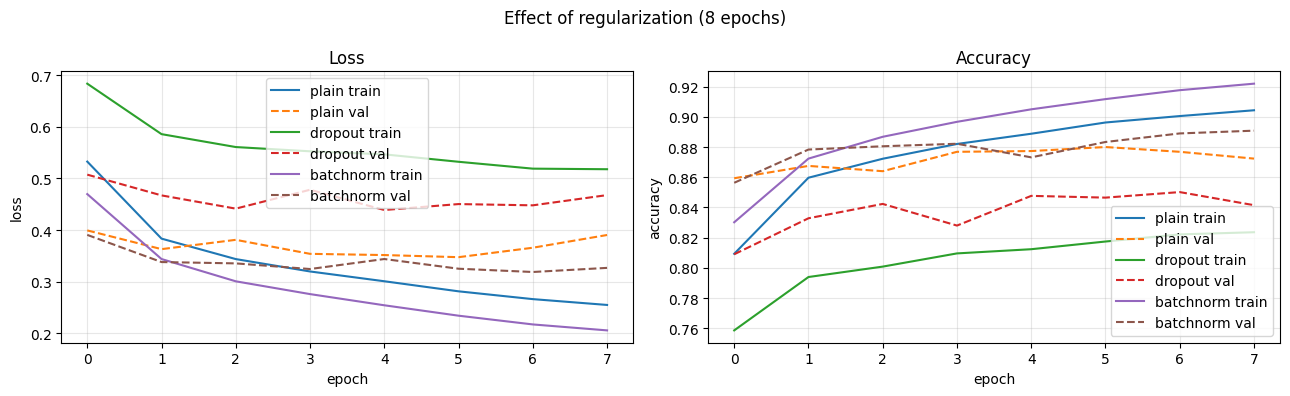

In [ ]:
# Three variants of the same architecture: plain, dropout, batch-norm
def make_variant(kind):
    return MLPClassifier(
        hidden=(512, 256),
        p_drop = 0.4 if kind == "dropout"   else 0.0,
        use_bn = (kind == "batchnorm")
    ).to(device)

histories = {}
for name in ["plain", "dropout", "batchnorm"]:
    print(f"--- training {name} ---")
    set_seed(0)                       # same init for fair comparison
    m   = make_variant(name)
    opt = optim.SGD(m.parameters(), lr=0.1, momentum=0.9)
    histories[name] = train(m, train_loader, val_loader,
                            epochs=8, optimizer=opt, verbose=False)
    _, test_acc = evaluate(m, test_loader, nn.CrossEntropyLoss(), device)
    print(f"   test acc = {test_acc:.4f}")

plot_history(histories, title="Effect of regularization (8 epochs)")


---
## 20. Weight initialization

Initialization matters: bad initialization causes activations / gradients to **vanish** or **explode** through depth.

* **Xavier / Glorot** (good for tanh/sigmoid): `Var(W) = 1/n_in` (or `2/(n_in+n_out)`).
* **He / Kaiming** (good for ReLU): `Var(W) = 2/n_in`.
* **Zero** for biases is fine.
* **Never** initialize all weights to the same constant (symmetry not broken — every neuron in a layer would learn the same thing).


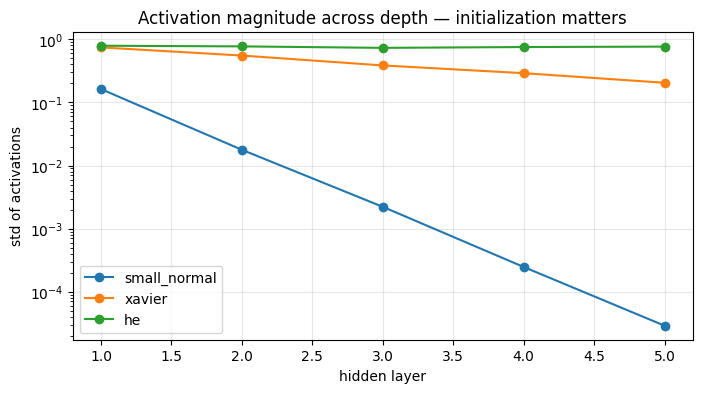


With small-normal init, activations vanish to ~0; predictions become useless.
Xavier preserves signal in tanh/sigmoid networks; He is the right choice for ReLU.


In [ ]:
# Compare activation statistics under three initialization schemes,
# in a deep network — the key reason He init exists.
def make_deep_mlp(init):
    layers = [nn.Flatten()]
    sizes = [784, 256, 256, 256, 256, 256, 10]
    for i in range(len(sizes)-1):
        lin = nn.Linear(sizes[i], sizes[i+1])
        if   init == "small_normal":
            nn.init.normal_(lin.weight, std=0.01)
        elif init == "xavier":
            nn.init.xavier_normal_(lin.weight)
        elif init == "he":
            nn.init.kaiming_normal_(lin.weight, nonlinearity='relu')
        nn.init.zeros_(lin.bias)
        layers.append(lin)
        if i < len(sizes)-2: layers.append(nn.ReLU())
    return nn.Sequential(*layers)

xb, _ = next(iter(train_loader))
xb = xb.to(device)

stats = {}
for init in ["small_normal", "xavier", "he"]:
    m = make_deep_mlp(init).to(device)
    activations = []
    h = xb
    for layer in m:
        h = layer(h)
        if isinstance(layer, nn.ReLU):
            activations.append(h.detach().std().item())
    stats[init] = activations

fig, ax = plt.subplots(figsize=(8,4))
for init, vals in stats.items():
    ax.plot(range(1, len(vals)+1), vals, marker='o', label=init)
ax.set_xlabel("hidden layer"); ax.set_ylabel("std of activations")
ax.set_yscale("log"); ax.grid(alpha=0.3); ax.legend()
ax.set_title("Activation magnitude across depth — initialization matters");
plt.show()

print("\nWith small-normal init, activations vanish to ~0; predictions become useless.")
print("Xavier preserves signal in tanh/sigmoid networks; He is the right choice for ReLU.")


---
## 21. Optimizers in PyTorch

PyTorch implements many optimizers in `torch.optim`. They share an interface:

```python
optimizer = optim.<Name>(model.parameters(), lr=..., weight_decay=...)
```

We compare **SGD**, **SGD+momentum**, **Adam**, and **AdamW** on the same model and seed.


SGD             final val acc = 0.8753
SGD+momentum    final val acc = 0.8697
Adam            final val acc = 0.8850
AdamW           final val acc = 0.8847


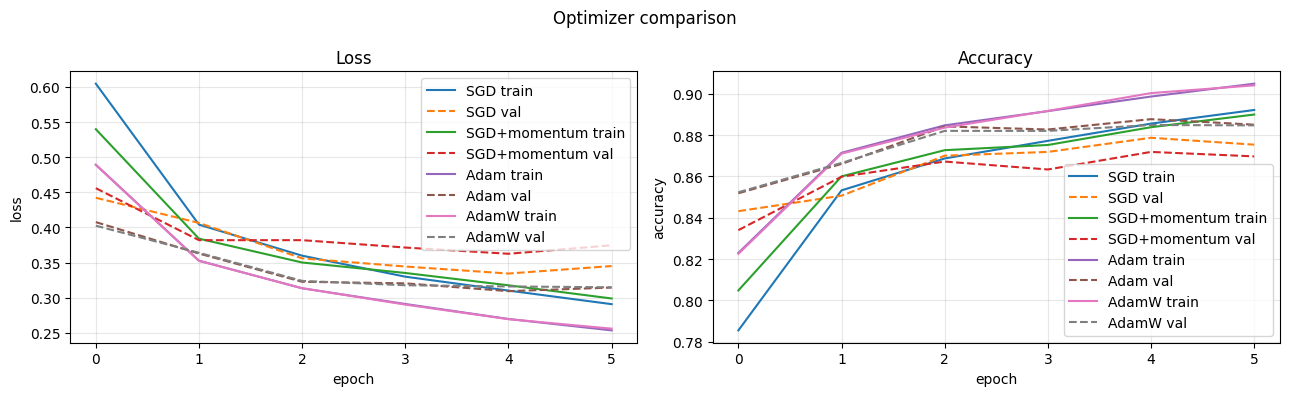

In [ ]:
def fresh_model():
    set_seed(0)
    return MLPClassifier(hidden=(256, 128)).to(device)

opt_factories = {
    "SGD"          : lambda p: optim.SGD(p,  lr=0.1),
    "SGD+momentum" : lambda p: optim.SGD(p,  lr=0.1, momentum=0.9),
    "Adam"         : lambda p: optim.Adam(p, lr=1e-3),
    "AdamW"        : lambda p: optim.AdamW(p, lr=1e-3, weight_decay=1e-4),
}

opt_histories = {}
for name, fac in opt_factories.items():
    m = fresh_model()
    opt = fac(m.parameters())
    opt_histories[name] = train(m, train_loader, val_loader,
                                epochs=6, optimizer=opt, verbose=False)
    print(f"{name:14s}  final val acc = {opt_histories[name]['val_acc'][-1]:.4f}")

plot_history(opt_histories, title="Optimizer comparison")


---
## 22. Learning-rate schedules

A single learning rate is rarely optimal: high lr early to make progress, low lr late to fine-tune. Common schedules:

* **StepLR** — multiply lr by γ every k epochs.
* **ExponentialLR** — multiply lr by γ every epoch.
* **CosineAnnealing** — smoothly decay along a cosine curve.
* **ReduceLROnPlateau** — drop lr when val loss stops improving.
* **OneCycleLR / Warm-up** — popular modern recipes.


/tmp/ipykernel_1464/1658469162.py:9: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  sched.step()


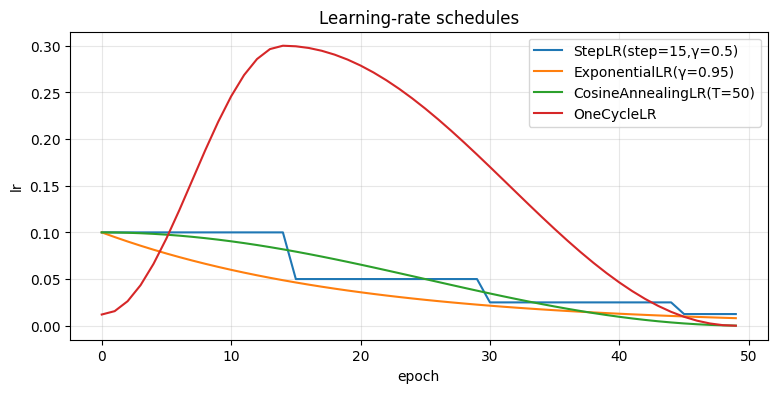

In [ ]:
# Visualize 4 schedules over 50 epochs (without training, just to show curves)
def lr_curve(scheduler_factory, epochs=50):
    p = [torch.zeros(1, requires_grad=True)]
    opt = optim.SGD(p, lr=0.1)
    sched = scheduler_factory(opt)
    lrs = []
    for _ in range(epochs):
        lrs.append(opt.param_groups[0]['lr'])
        sched.step()
    return lrs

schedules = {
    "StepLR(step=15,γ=0.5)"   : lambda o: optim.lr_scheduler.StepLR(o, step_size=15, gamma=0.5),
    "ExponentialLR(γ=0.95)"   : lambda o: optim.lr_scheduler.ExponentialLR(o, gamma=0.95),
    "CosineAnnealingLR(T=50)" : lambda o: optim.lr_scheduler.CosineAnnealingLR(o, T_max=50),
    "OneCycleLR"              : lambda o: optim.lr_scheduler.OneCycleLR(
        o, max_lr=0.3, total_steps=50, pct_start=0.3),
}

plt.figure(figsize=(9,4))
for name, fac in schedules.items():
    plt.plot(lr_curve(fac), label=name)
plt.xlabel("epoch"); plt.ylabel("lr"); plt.title("Learning-rate schedules")
plt.legend(); plt.grid(alpha=0.3); plt.show()


---
## 23. Diagnosing training — bias, variance, learning curves

The shape of the **train vs validation** loss/accuracy curves is your most reliable diagnostic.

| Observation                                | Diagnosis                  | Remedy                                            |
|--------------------------------------------|----------------------------|---------------------------------------------------|
| High train loss & high val loss            | **Underfitting (high bias)** | Bigger model, more epochs, better features, lower regularization |
| Low train loss, much higher val loss       | **Overfitting (high variance)** | More data / aug, dropout, weight decay, early stopping, smaller model |
| Loss not decreasing at all                 | LR too high / wrong loss / bug | Decrease lr, check loss scale, gradient sanity   |
| Loss exploding to NaN                      | LR too high / bad init       | Decrease lr, gradient clipping, He init          |
| Train loss decreasing, val loss flat then rising | Overfitting starting     | Regularize, early-stop                           |

Below, we deliberately overfit a tiny subset of Fashion-MNIST to *see* high variance, then add dropout to *see* it shrink.


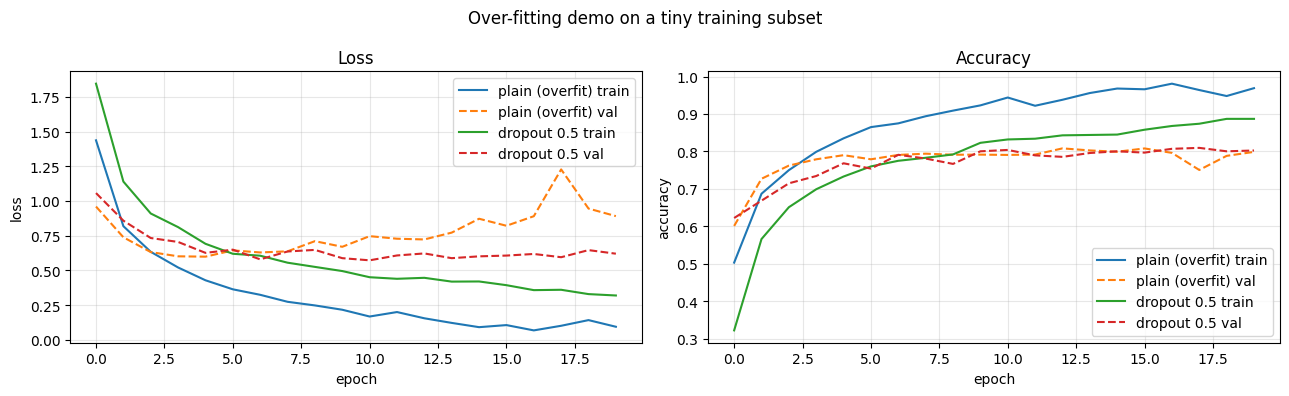

In [ ]:
# Take only 1000 training images to provoke over-fitting
small_train = torch.utils.data.Subset(train_set, list(range(1000)))
small_loader = DataLoader(small_train, batch_size=64, shuffle=True)

def quick_train(model, epochs=20, label=""):
    opt = optim.Adam(model.parameters(), lr=1e-3)
    return train(model, small_loader, val_loader,
                 epochs=epochs, optimizer=opt, verbose=False)

set_seed(0); m_over = MLPClassifier(hidden=(512,512,512)).to(device)
hist_over = quick_train(m_over, label="overfit")
set_seed(0); m_drop = MLPClassifier(hidden=(512,512,512), p_drop=0.5).to(device)
hist_drop = quick_train(m_drop, label="dropout")

plot_history({"plain (overfit)": hist_over,
              "dropout 0.5"    : hist_drop},
             title="Over-fitting demo on a tiny training subset")


---
## 24. Saving, loading, and reproducibility

**Save weights only** (recommended) — small, portable, decoupled from the class definition. To resume training, also save optimizer state.


In [ ]:
# Save
torch.save(baseline.state_dict(), "baseline_mlp.pth")
print("Saved 'baseline_mlp.pth'")

# Load (must rebuild the same architecture first)
restored = MLPClassifier(hidden=(256, 128)).to(device)
restored.load_state_dict(torch.load("baseline_mlp.pth", map_location=device))
restored.eval()

# Sanity check
_, acc = evaluate(restored, test_loader, nn.CrossEntropyLoss(), device)
print(f"Restored model test acc: {acc:.4f}")


Saved 'baseline_mlp.pth'
Restored model test acc: 0.8597


---
## 25. What's next — bridge to CNNs

A reasonable MLP gets ~88% on Fashion-MNIST. CNNs routinely exceed 92–94%, with **far fewer parameters**, because they exploit two key properties of images:

1. **Locality** — nearby pixels are correlated.
2. **Translation invariance** — a sleeve looks like a sleeve regardless of where it appears.

MLPs treat 784 pixels as 784 unrelated features and learn to ignore irrelevant ones from data alone. CNNs **bake those priors directly into their architecture** through convolution and pooling — and that's the topic of the next tutorial.

---

## Recap — everything you now know

* Tensors, broadcasting, GPU acceleration, autograd.
* The perceptron, its learning rule, and why one neuron isn't enough.
* The XOR problem and how MLPs solve it.
* Architectural choices: depth, width, hidden layers.
* All major activation functions and where to use each.
* The feedforward pass.
* MSE, cross-entropy, and how loss shapes learning.
* Batch / stochastic / mini-batch gradient descent.
* Backpropagation — derived, hand-coded, and verified against autograd.
* Building, training, and evaluating networks with `nn.Module` and `DataLoader`.
* Regularization (weight decay, dropout, batch-norm), initialization (Xavier, He), modern optimizers (Momentum, Adam, AdamW), and learning-rate schedules.
* Diagnosing training with learning curves; recognizing under- and over-fitting.
* Saving, loading, reproducibility — the engineering basics.

Up next: **Convolutional Neural Networks**.
